# Drone Swarm Assignment — Dataset Generator

Generates **10 000 PyG `Data` samples** for training a **decentralised Hungarian-style assignment model**.

### Why this design is good for a decentralised model

Each drone needs to negotiate a slot without global communication. The dataset is designed so that:

- **No global features are stored** — only raw positions (`drone_pos`, `slots`). Node features (relative distances, edge weights) are built at training time from each drone's local perspective.
- **Ground truth via Hungarian** gives the globally optimal assignment as supervision signal. The model learns to approximate this optimum in a decentralised, message-passing way — similar to auction algorithms or belief propagation.
- **Stratified sampling** across 6 formations × 13 swarm sizes prevents specialisation on one geometry.
- **Minimum slot spacing (≥ 0.30 m)** ensures assignments are geometrically non-trivial and physically realisable.

| Field | Shape | Dtype | Notes |
|---|---|---|---|
| `drone_pos` | (N, 2) | float32 | Raw drone XY in arena |
| `slots` | (N, 2) | float32 | Formation slot XY (centred at CoG) |
| `y` | (N,) | int64 | GT slot index for each drone |
| `formation_id` | scalar | int64 | 0-A 1-V 2-W 3-O 4-Rect 5-Tri |
| `n_drones` | scalar | int64 | N ∈ [8, 20] |

In [1]:
# ── Cell 1 · Imports & constants ────────────────────────────────────────────
import os, math, random, collections
import numpy as np
from scipy.optimize import linear_sum_assignment
import torch
from torch_geometric.data import Data
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
ARENA_SIZE   = 10.0
N_MIN, N_MAX = 8, 20
MIN_SLOT_SEP = 0.30
N_SAMPLES    = 10_000
SAVE_PATH    = './dataset/negotiator_dataset_v1.pt'

FORMATION_NAMES = ['A', 'V', 'W', 'O', 'Rectangle', 'Triangle']
N_FORMATIONS    = len(FORMATION_NAMES)

os.makedirs('./dataset', exist_ok=True)
print('Environment ready ✓')

Environment ready ✓


In [2]:
# ── Cell 2 · Formation geometry generators ───────────────────────────────────

def _enforce_min_sep(pts: np.ndarray, min_sep: float) -> np.ndarray:
    """
    Scale a centred point-cloud up until every pairwise distance >= min_sep.
    Guards against duplicate points (min_d == 0) by jittering them apart first.
    """
    if len(pts) < 2:
        return pts
    # Remove exact duplicates with tiny jitter
    seen = {}
    for i, p in enumerate(pts):
        key = (round(float(p[0]), 6), round(float(p[1]), 6))
        if key in seen:
            pts[i] += np.random.uniform(-1e-3, 1e-3, size=2)
        else:
            seen[key] = i

    diff  = pts[:, None, :] - pts[None, :, :]   # (N, N, 2)
    dists = np.linalg.norm(diff, axis=-1)        # (N, N)
    np.fill_diagonal(dists, np.inf)
    min_d = dists.min()
    if min_d > 0 and min_d < min_sep:
        pts = pts * (min_sep / min_d)
    elif min_d == 0:
        # Shouldn't happen after jitter, but safeguard
        pts = pts + np.random.uniform(-0.01, 0.01, size=pts.shape)
        pts = _enforce_min_sep(pts, min_sep)
    return pts


def _linspace_seg(a: np.ndarray, b: np.ndarray, n: int, include_end: bool = False) -> list:
    """n evenly-spaced points along segment a→b. include_end controls whether b is included."""
    total = n + 1 if not include_end else n
    pts = []
    for i in range(total if include_end else n):
        t = i / max(n - 1 if include_end else n, 1)
        pts.append(a + t * (b - a))
    return pts


def gen_A(n: int) -> np.ndarray:
    """
    A-formation: two angled legs + horizontal crossbar.
    Points are placed on segments WITHOUT repeating the shared apex vertex.
    """
    apex       = np.array([0.0,  1.0])
    left_base  = np.array([-1.2, -1.0])
    right_base = np.array([ 1.2, -1.0])

    # Distribute across 3 segments: left-leg, right-leg, crossbar
    n_leg   = max(3, int(n * 0.65))
    n_cross = max(2, n - n_leg)
    n_left  = n_leg // 2
    n_right = n_leg - n_left

    pts = []
    # Left leg: base → apex, NOT including apex (to avoid duplicate)
    for i in range(n_left):
        t = i / n_left
        pts.append(left_base + t * (apex - left_base))
    # Right leg: apex → base, NOT including apex
    for i in range(n_right):
        t = i / n_right
        pts.append(apex + t * (right_base - apex))

    # Crossbar at mid-height (45% up each leg)
    frac = 0.45
    cl = left_base  + frac * (apex - left_base)
    cr = right_base + frac * (apex - right_base)
    for i in range(n_cross):
        t = i / max(n_cross - 1, 1)
        pts.append(cl + t * (cr - cl))

    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


def gen_V(n: int) -> np.ndarray:
    """V-formation: two diverging legs from bottom apex, apex NOT duplicated."""
    apex      = np.array([0.0,  -1.0])
    left_tip  = np.array([-1.8,  1.0])
    right_tip = np.array([ 1.8,  1.0])

    n_left  = n // 2
    n_right = n - n_left
    pts = []
    # Left: apex → left_tip, skip apex on right
    for i in range(n_left):
        t = i / max(n_left - 1, 1)
        pts.append(apex + t * (left_tip - apex))
    # Right: start one step in from apex
    for i in range(1, n_right + 1):
        t = i / n_right
        pts.append(apex + t * (right_tip - apex))

    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


def gen_W(n: int) -> np.ndarray:
    """W-formation: four connected segments, shared vertices excluded."""
    tops    = [np.array([-2.0, 1.0]),
               np.array([ 0.0, 1.0]),
               np.array([ 2.0, 1.0])]
    valleys = [np.array([-1.0, -1.0]),
               np.array([ 1.0, -1.0])]

    # 4 segments; each open at its end vertex to avoid duplicates
    segs = [
        (tops[0],    valleys[0]),
        (valleys[0], tops[1]),
        (tops[1],    valleys[1]),
        (valleys[1], tops[2]),
    ]
    n_per = max(2, n // 4)
    extra = n - n_per * 4  # may be negative → handled by slicing

    pts = []
    for s, (a, b) in enumerate(segs):
        cnt = n_per + (1 if s < extra else 0)
        for i in range(cnt):
            t = i / cnt          # open interval: [0, 1)
            pts.append(a + t * (b - a))

    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


def gen_O(n: int) -> np.ndarray:
    """O-formation: uniform ring (always distinct)."""
    angles = np.linspace(0, 2 * math.pi, n, endpoint=False)
    pts    = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    pts   -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


def gen_Rectangle(n: int) -> np.ndarray:
    """Rectangle-formation: perimeter of a 2:1 rectangle (open at start vertex)."""
    w, h  = 2.0, 1.0
    perim = 2 * (w + h)
    # Open interval [0, perim): avoids duplicate start/end
    ts    = np.linspace(0, perim, n, endpoint=False)
    pts   = []
    for t in ts:
        if t < w:
            pts.append([-w/2 + t, -h/2])
        elif t < w + h:
            pts.append([w/2, -h/2 + (t - w)])
        elif t < 2*w + h:
            pts.append([w/2 - (t - w - h), h/2])
        else:
            pts.append([-w/2, h/2 - (t - 2*w - h)])
    pts = np.array(pts, dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


def gen_Triangle(n: int) -> np.ndarray:
    """Triangle-formation: equilateral perimeter (open at each vertex)."""
    v0 = np.array([0.0,                math.sqrt(3)/2 * 2/3])
    v1 = np.array([-1.0,             -math.sqrt(3)/2 * 1/3])
    v2 = np.array([ 1.0,             -math.sqrt(3)/2 * 1/3])
    sides = [(v0, v1), (v1, v2), (v2, v0)]

    n_side = n // 3
    extras = n - n_side * 3
    pts = []
    for idx, (a, b) in enumerate(sides):
        cnt = n_side + (1 if idx < extras else 0)
        for i in range(cnt):
            t = i / max(cnt, 1)    # open: vertex b belongs to next segment
            pts.append(a + t * (b - a))

    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts, MIN_SLOT_SEP)


FORMATION_GENERATORS = [
    gen_A, gen_V, gen_W, gen_O, gen_Rectangle, gen_Triangle
]

# ── Smoke-test: check no NaNs and min-sep satisfied for all n ────────────────
print('Testing formation generators...')
for fid, gen in enumerate(FORMATION_GENERATORS):
    for n in range(N_MIN, N_MAX + 1):
        pts = gen(n).astype(np.float32)
        assert not np.isnan(pts).any(), f'{FORMATION_NAMES[fid]} n={n}: NaN detected'
        assert not np.isinf(pts).any(), f'{FORMATION_NAMES[fid]} n={n}: Inf detected'
        assert len(pts) == n, f'{FORMATION_NAMES[fid]} n={n}: expected {n} pts, got {len(pts)}'
        diff  = pts[:, None, :] - pts[None, :, :]
        dists = np.linalg.norm(diff, axis=-1)
        np.fill_diagonal(dists, np.inf)
        assert dists.min() >= MIN_SLOT_SEP - 1e-4, (
            f'{FORMATION_NAMES[fid]} n={n}: min_sep={dists.min():.4f} < {MIN_SLOT_SEP}')
print('All formation generators valid ✓')

Testing formation generators...
All formation generators valid ✓


In [3]:
# ── Cell 3 · Sample generator ────────────────────────────────────────────────

def make_sample(formation_id: int, n: int) -> Data:
    """
    Build one PyG Data object:
      1. Place N drones uniformly at random in [0, ARENA_SIZE]².
      2. Generate N formation slots centred at swarm CoG.
      3. Solve optimal assignment via Hungarian algorithm (min total Euclidean dist).
    """
    # Drone positions
    drone_pos = np.random.uniform(0, ARENA_SIZE, size=(n, 2)).astype(np.float32)
    cog       = drone_pos.mean(axis=0)

    # Formation slots (centred at origin → shifted to CoG)
    gen       = FORMATION_GENERATORS[formation_id]
    slots_rel = gen(n).astype(np.float32)
    slots     = slots_rel + cog

    # Hungarian assignment: minimise total Euclidean distance
    cost              = np.linalg.norm(
                            drone_pos[:, None, :] - slots[None, :, :], axis=-1)
    row_ind, col_ind  = linear_sum_assignment(cost)
    assignment        = np.empty(n, dtype=np.int64)
    assignment[row_ind] = col_ind          # assignment[i] = slot for drone i

    return Data(
        drone_pos    = torch.from_numpy(drone_pos),
        slots        = torch.from_numpy(slots),
        y            = torch.from_numpy(assignment),
        formation_id = torch.tensor(formation_id, dtype=torch.long),
        n_drones     = torch.tensor(n,            dtype=torch.long),
    )


# Quick smoke-test
sample = make_sample(0, 10)
print('Sample fields:')
for k, v in sample:
    print(f'  {k:15s}: shape={tuple(v.shape)}, dtype={v.dtype}')

Sample fields:
  y              : shape=(10,), dtype=torch.int64
  drone_pos      : shape=(10, 2), dtype=torch.float32
  slots          : shape=(10, 2), dtype=torch.float32
  formation_id   : shape=(), dtype=torch.int64
  n_drones       : shape=(), dtype=torch.int64


In [4]:
# ── Cell 4 · Stratified dataset generation ───────────────────────────────────

def build_dataset(n_samples: int) -> list:
    """
    Stratify evenly across:
      - 6 formations
      - 13 swarm sizes  (8 … 20 inclusive)
    Total strata = 6 × 13 = 78.
    Each stratum gets floor(n_samples / 78) samples;
    the remainder is distributed randomly across strata.
    """
    n_sizes  = list(range(N_MIN, N_MAX + 1))
    strata   = [(f, n) for f in range(N_FORMATIONS) for n in n_sizes]
    n_strata = len(strata)

    base, rem = divmod(n_samples, n_strata)
    counts    = {s: base for s in strata}
    for s in random.sample(strata, rem):
        counts[s] += 1

    dataset = []
    pbar    = tqdm(total=n_samples, desc='Generating samples')
    for (fid, n), cnt in counts.items():
        for _ in range(cnt):
            dataset.append(make_sample(fid, n))
            pbar.update(1)
    pbar.close()

    random.shuffle(dataset)
    return dataset


dataset = build_dataset(N_SAMPLES)
print(f'\nDataset size: {len(dataset)} samples')

Generating samples:   0%|          | 0/10000 [00:00<?, ?it/s]


Dataset size: 10000 samples


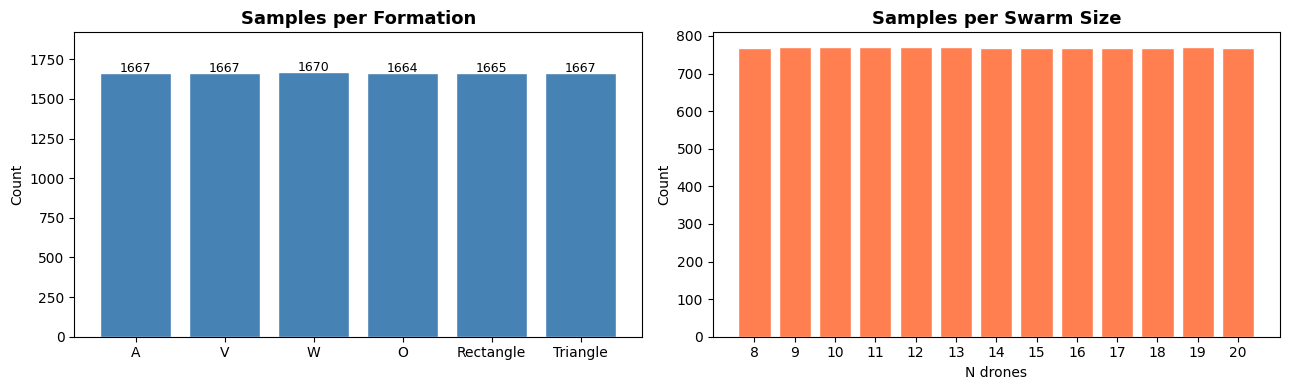

Stratification verified ✓


In [5]:
# ── Cell 5 · Verify stratification ───────────────────────────────────────────

form_counts = collections.Counter(int(d.formation_id) for d in dataset)
size_counts = collections.Counter(int(d.n_drones)     for d in dataset)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(FORMATION_NAMES, [form_counts[i] for i in range(N_FORMATIONS)],
       color='steelblue', edgecolor='white')
ax.set_title('Samples per Formation', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(form_counts.values()) * 1.15)
for i, v in enumerate([form_counts[i] for i in range(N_FORMATIONS)]):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)

ax = axes[1]
sizes = sorted(size_counts)
ax.bar(sizes, [size_counts[s] for s in sizes], color='coral', edgecolor='white')
ax.set_title('Samples per Swarm Size', fontsize=13, fontweight='bold')
ax.set_xlabel('N drones')
ax.set_ylabel('Count')
ax.set_xticks(sizes)

plt.tight_layout()
plt.savefig('./dataset/stratification_check.png', dpi=120)
plt.show()
print('Stratification verified ✓')

In [6]:
# ── Cell 6 · Save dataset ────────────────────────────────────────────────────
torch.save(dataset, SAVE_PATH)
file_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Saved {len(dataset)} samples → {SAVE_PATH}  ({file_mb:.1f} MB)')

Saved 10000 samples → ./dataset/negotiator_dataset_v1.pt  (17.5 MB)


In [7]:
# ── Cell 7 · Load & sanity-check round-trip ──────────────────────────────────
loaded = torch.load(SAVE_PATH, weights_only=False)
assert len(loaded) == N_SAMPLES, f'Expected {N_SAMPLES}, got {len(loaded)}'

errors = 0
for _ in range(500):
    d = random.choice(loaded)
    n = int(d.n_drones)

    # Assignment must be a valid permutation
    if set(d.y.tolist()) != set(range(n)):
        errors += 1

    # Min slot separation
    pts  = d.slots.numpy()
    diff = pts[:, None, :] - pts[None, :, :]
    dm   = np.linalg.norm(diff, axis=-1)
    np.fill_diagonal(dm, np.inf)
    if dm.min() < MIN_SLOT_SEP - 1e-4:
        errors += 1

    # No NaNs
    if np.isnan(d.drone_pos.numpy()).any() or np.isnan(d.slots.numpy()).any():
        errors += 1

print(f'Sanity checks: {500 - errors}/500 passed', '✓' if errors == 0 else f'  ← {errors} failures!')

Sanity checks: 500/500 passed ✓


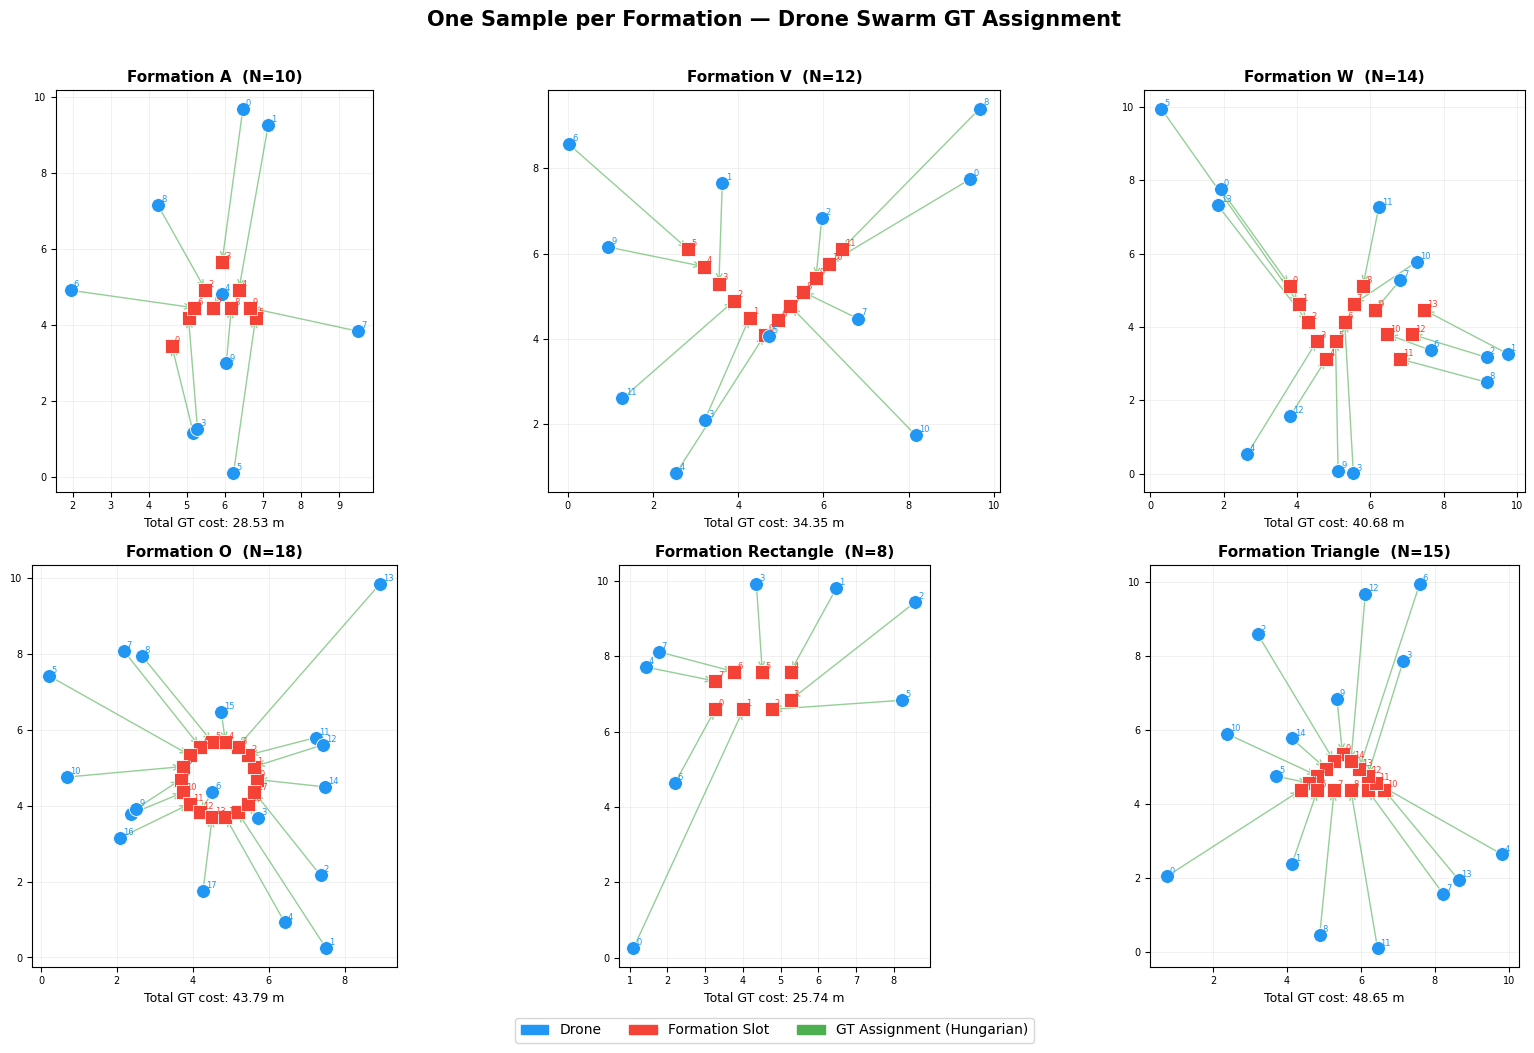

Visualisation saved → ./dataset/formation_examples.png


In [8]:
# ── Cell 8 · Visualisation — one sample per formation ────────────────────────

# Pick the first occurrence of each formation
examples = {}
for d in loaded:
    fid = int(d.formation_id)
    if fid not in examples:
        examples[fid] = d
    if len(examples) == N_FORMATIONS:
        break

DRONE_COLOR  = '#2196F3'
SLOT_COLOR   = '#F44336'
ARROW_COLOR  = '#4CAF50'

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('One Sample per Formation — Drone Swarm GT Assignment',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (fid, d) in zip(axes.flat, sorted(examples.items())):
    drones = d.drone_pos.numpy()
    slots  = d.slots.numpy()
    assign = d.y.numpy()
    n      = int(d.n_drones)

    # Assignment arrows
    for i in range(n):
        ax.annotate('',
                    xy     =(slots[assign[i], 0], slots[assign[i], 1]),
                    xytext =(drones[i, 0], drones[i, 1]),
                    arrowprops=dict(arrowstyle='->', color=ARROW_COLOR,
                                   lw=1.0, alpha=0.6))

    ax.scatter(slots[:, 0],  slots[:, 1],  s=100, c=SLOT_COLOR,
               marker='s', zorder=3, edgecolors='white', lw=0.6, label='Slot')
    ax.scatter(drones[:, 0], drones[:, 1], s=100, c=DRONE_COLOR,
               marker='o', zorder=4, edgecolors='white', lw=0.6, label='Drone')

    for i in range(n):
        ax.text(drones[i,0]+0.08, drones[i,1]+0.08, str(i),
                fontsize=6, color=DRONE_COLOR, zorder=5)
        ax.text(slots[i,0]+0.08,  slots[i,1]+0.08,  str(i),
                fontsize=6, color=SLOT_COLOR,  zorder=5)

    cost = sum(np.linalg.norm(drones[i] - slots[assign[i]]) for i in range(n))
    ax.set_title(f'Formation {FORMATION_NAMES[fid]}  (N={n})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Total GT cost: {cost:.2f} m', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.tick_params(labelsize=7)

handles = [
    mpatches.Patch(color=DRONE_COLOR, label='Drone'),
    mpatches.Patch(color=SLOT_COLOR,  label='Formation Slot'),
    mpatches.Patch(color=ARROW_COLOR, label='GT Assignment (Hungarian)'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('./dataset/formation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation saved → ./dataset/formation_examples.png')

In [9]:
# ── Cell 9 · Model architecture notes ───────────────────────────────────────
print("""
════════════════════════════════════════════════════════════════════
  Dataset design notes — decentralised Hungarian-style model
════════════════════════════════════════════════════════════════════

  GLOBAL OPTIMUM AS SUPERVISION (Hungarian GT)
  ──────────────────────────────────────────────
  Hungarian gives the Pareto-optimal, conflict-free assignment
  in O(N³). A decentralised GNN reproduces this via local
  message-passing — equivalent to a learned auction / belief-
  propagation procedure without a central coordinator.

  FEATURE CONSTRUCTION AT TRAINING TIME (not stored here)
  ─────────────────────────────────────────────────────────
  From drone_pos and slots, build per-drone node features:
    • Relative displacement to each slot   Δxᵢⱼ = sⱼ − pᵢ
    • Euclidean distance                   dᵢⱼ
    • Inter-drone relative vectors         Δxᵢₖ = pₖ − pᵢ
  These feed GNN message-passing layers so each drone
  aggregates neighbour information before choosing its slot.

  RECOMMENDED MODEL HEADS
  ────────────────────────
  • Cross-entropy:  −log p(y[i] | local messages)
    Each drone outputs a softmax over N slots; y[i] is the GT.
  • Sinkhorn / optimal-transport head for guaranteed conflict-
    free output (no two drones claim the same slot).

  RECOMMENDED TRAINING PARITY (local_negotiator.py / V3)
  ───────────────────────────────────────────────────────
  • COMM_RADIUS = 3.0 m        drone–drone message passing
  • SLOT_VISIBILITY_RADIUS = 5.0 m   local slot bidding range
  • MAX_GOSSIP_ROUNDS = 8      multi-hop conflict resolution

  SCALABILITY
  ────────────
  Training on N ∈ [8, 20] makes the model transferable to
  larger swarms at inference time — a key advantage over
  centralised O(N³) solvers.
════════════════════════════════════════════════════════════════════
""")


════════════════════════════════════════════════════════════════════
  Dataset design notes — decentralised Hungarian-style model
════════════════════════════════════════════════════════════════════

  GLOBAL OPTIMUM AS SUPERVISION (Hungarian GT)
  ──────────────────────────────────────────────
  Hungarian gives the Pareto-optimal, conflict-free assignment
  in O(N³). A decentralised GNN reproduces this via local
  message-passing — equivalent to a learned auction / belief-
  propagation procedure without a central coordinator.

  FEATURE CONSTRUCTION AT TRAINING TIME (not stored here)
  ─────────────────────────────────────────────────────────
  From drone_pos and slots, build per-drone node features:
    • Relative displacement to each slot   Δxᵢⱼ = sⱼ − pᵢ
    • Euclidean distance                   dᵢⱼ
    • Inter-drone relative vectors         Δxᵢₖ = pₖ − pᵢ
  These feed GNN message-passing layers so each drone
  aggregates neighbour information before choosing its slot.

  RECOMM